# PRISMA--SIT spectral-support audit: cap seed sensitivity

This notebook recomputes the complete field-level spectral-support audit independently for each capped-export seed.

For each seed it performs:

1. loading of the 25 capped scene exports;
2. concatenation of `X`, `y`, `field_id`, and `scene_id`;
3. L2 normalization of spectra;
4. robust class-prototype estimation;
5. SAD/Euclidean distance calculation to the assigned SIT-class prototype;
6. class-wise robust normalization using median/IQR;
7. pixel-level spectral-support score calculation;
8. field--scene aggregation;
9. q10/q30/q90 operating-threshold assignment;
10. SA/IS/ST stratum assignment;
11. saving of the field-level audit table for each seed.

The notebook assumes scene folders named like:

```text
python_data_Scena_12_seed_49
```

inside `DATA_ROOT`.


In [1]:
from pathlib import Path
import re
import gc
import warnings

import numpy as np
import pandas as pd

try:
    from scipy.stats import spearmanr
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scipy available:", SCIPY_AVAILABLE)


numpy 2.4.6
pandas 2.3.3
scipy available: True


## 1. Configuration

Edit `DATA_ROOT` and `OUTPUT_ROOT` before running.

For Kaggle, if your dataset is mounted under `/kaggle/input/seed2`, use:

```python
DATA_ROOT = Path("/kaggle/input/seed2")
OUTPUT_ROOT = Path("/kaggle/working/audit_seed_outputs")
```

For local execution, use your local path, for example:

```python
DATA_ROOT = Path("/Users/andreaguerriero/Documents/Matlab/PRISMA/SEED2")
```


In [3]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------

DATA_ROOT = Path("/kaggle/input/datasets/andgu2026/new-seed/SEED2")  # <-- change if needed
OUTPUT_ROOT = Path("/kaggle/working/audit_seed_outputs")

SEEDS = [49, 7, 123]
REFERENCE_SEED = 49

EXPECTED_N_SCENES = 25

# Class support and field eligibility
MIN_CLASS_PIXELS = 1000
MIN_FIELD_PIXELS = 10

# Operating quantiles
Q_SUPPORT_LOW = 0.10
Q_SUPPORT_MID = 0.30
Q_OUTLIER_HIGH = 0.90

# Numerical stability
EPS = 1e-12

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SEEDS:", SEEDS)


DATA_ROOT: /kaggle/input/datasets/andgu2026/new-seed/SEED2
OUTPUT_ROOT: /kaggle/working/audit_seed_outputs
SEEDS: [49, 7, 123]


## 2. Helper functions

In [24]:
def parse_scene_id(folder_name: str) -> str:
    """
    Parse a folder name like:
    python_data_Scena_12_seed_49 -> Scena_12
    """
    m = re.match(r"python_data_(Scena_\d+)_seed_\d+$", folder_name)
    if m is None:
        raise ValueError(f"Cannot parse scene_id from folder name: {folder_name}")
    return m.group(1)


def scene_sort_key(path: Path):
    scene_id = parse_scene_id(path.name)
    n = int(scene_id.split("_")[1])
    return n


def find_scene_dirs(data_root: Path, seed: int):
    dirs = sorted(
        data_root.glob(f"python_data_Scena_*_seed_{seed}"),
        key=scene_sort_key
    )
    return dirs


def read_vector_csv(path: Path, dtype=None):
    arr = pd.read_csv(path, header=None).values.ravel()
    if dtype is not None:
        arr = arr.astype(dtype)
    return arr


def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Row-wise L2 normalization.
    Invalid rows or zero-norm rows remain finite because denominator is clipped.
    """
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1).astype(np.float32)
    norms = np.maximum(norms, eps).astype(np.float32)
    return X / norms[:, None]


def iqr_np(x: np.ndarray) -> float:
    q75, q25 = np.nanpercentile(x, [75, 25])
    return float(q75 - q25)


def safe_arccos_dot(X_norm: np.ndarray, p_norm: np.ndarray) -> np.ndarray:
    dots = np.sum(X_norm * p_norm[None, :], axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    return np.arccos(dots).astype(np.float32)


def compute_prototypes(X_norm: np.ndarray, y: np.ndarray, min_class_pixels: int = 1000):
    """
    Estimate one robust spectral prototype per supported class.

    Prototype = class-wise median spectrum of L2-normalized pixels,
    then L2-normalized again.
    """
    classes, counts = np.unique(y, return_counts=True)
    class_counts = pd.DataFrame({
        "class_code": classes.astype(int),
        "n_pixels": counts.astype(int)
    })
    class_counts["supported"] = class_counts["n_pixels"] >= min_class_pixels

    supported_classes = class_counts.loc[class_counts["supported"], "class_code"].to_numpy()

    prototypes = {}

    for c in supported_classes:
        idx = (y == c)
        med = np.median(X_norm[idx, :], axis=0).astype(np.float32)
        norm = np.linalg.norm(med)
        if not np.isfinite(norm) or norm <= 0:
            warnings.warn(f"Class {c}: prototype norm is invalid; class skipped.")
            continue
        prototypes[int(c)] = (med / max(norm, EPS)).astype(np.float32)

    class_counts["prototype_available"] = class_counts["class_code"].map(lambda c: int(c) in prototypes)

    return prototypes, class_counts


def compute_pixel_distances_and_scores(X_norm: np.ndarray, meta: pd.DataFrame, prototypes: dict):
    """
    Compute SAD/EUC distances to the prototype of the assigned class.
    Then apply class-wise robust normalization and pixel support score.
    """
    n = len(meta)
    y = meta["y"].to_numpy()

    sad = np.full(n, np.nan, dtype=np.float32)
    euc = np.full(n, np.nan, dtype=np.float32)

    for c, proto in prototypes.items():
        idx = np.where(y == c)[0]
        if len(idx) == 0:
            continue

        Xc = X_norm[idx, :]

        sad[idx] = safe_arccos_dot(Xc, proto)
        diff = Xc - proto[None, :]
        euc[idx] = np.linalg.norm(diff, axis=1).astype(np.float32)

    pixel = meta.copy()
    pixel["sad"] = sad
    pixel["euc"] = euc
    pixel["supported_class"] = pixel["y"].map(lambda v: int(v) in prototypes)

    pixel["z_sad"] = np.nan
    pixel["z_euc"] = np.nan
    pixel["score"] = np.nan
    pixel["is_outlier_pixel"] = False

    stats_rows = []

    for c in sorted(prototypes.keys()):
        idx = (pixel["y"].to_numpy() == c)
        sad_c = pixel.loc[idx, "sad"].to_numpy(dtype=float)
        euc_c = pixel.loc[idx, "euc"].to_numpy(dtype=float)

        sad_med = float(np.nanmedian(sad_c))
        euc_med = float(np.nanmedian(euc_c))

        sad_iqr = iqr_np(sad_c)
        euc_iqr = iqr_np(euc_c)

        sad_q3 = float(np.nanpercentile(sad_c, 75))
        euc_q3 = float(np.nanpercentile(euc_c, 75))

        sad_thr = sad_q3 + 1.5 * sad_iqr
        euc_thr = euc_q3 + 1.5 * euc_iqr

        z_sad = (sad_c - sad_med) / (sad_iqr + EPS)
        z_euc = (euc_c - euc_med) / (euc_iqr + EPS)

        z = np.maximum.reduce([
            np.zeros_like(z_sad),
            z_sad,
            z_euc
        ])

        score = np.exp(-z)

        outlier = (sad_c > sad_thr) | (euc_c > euc_thr)

        pixel.loc[idx, "z_sad"] = z_sad
        pixel.loc[idx, "z_euc"] = z_euc
        pixel.loc[idx, "score"] = score
        pixel.loc[idx, "is_outlier_pixel"] = outlier

        stats_rows.append({
            "class_code": int(c),
            "n_pixels": int(np.sum(idx)),
            "sad_median": sad_med,
            "sad_iqr": sad_iqr,
            "sad_q3": sad_q3,
            "sad_outlier_threshold": sad_thr,
            "euc_median": euc_med,
            "euc_iqr": euc_iqr,
            "euc_q3": euc_q3,
            "euc_outlier_threshold": euc_thr,
            "pixel_outlier_rate": float(np.mean(outlier)),
            "score_median": float(np.nanmedian(score)),
        })

    class_distance_stats = pd.DataFrame(stats_rows)

    return pixel, class_distance_stats


def aggregate_field_scene(pixel: pd.DataFrame, min_field_pixels: int = 10):
    """
    Aggregate pixel-level scores to field--scene units.

    S_f = median score
    o_f = fraction of outlier pixels
    n_pixels = valid pixel count in field--scene unit
    """
    pixel = pixel.copy()
    pixel["field_id"] = pixel["field_id"].astype(str)
    pixel["scene_id"] = pixel["scene_id"].astype(str)
    pixel["unit_id"] = pixel["scene_id"] + "__" + pixel["field_id"]

    def mode_first(s):
        modes = s.mode(dropna=True)
        if len(modes) == 0:
            return np.nan
        return modes.iloc[0]

    grouped = pixel.groupby(["scene_id", "field_id", "unit_id"], sort=False)

    field = grouped.agg(
        class_code=("y", mode_first),
        n_pixels=("score", "size"),
        n_supported_pixels=("supported_class", "sum"),
        S_f=("score", "median"),
        o_f=("is_outlier_pixel", "mean"),
    ).reset_index()

    field["class_code"] = field["class_code"].astype("Int64")

    field["too_small"] = field["n_pixels"] < min_field_pixels
    field["insufficient_class_support"] = field["n_supported_pixels"] == 0
    field["eligible"] = (~field["too_small"]) & (~field["insufficient_class_support"])

    return field


def assign_strata(field: pd.DataFrame):
    """
    Apply q10/q30/q90 operating thresholds to eligible field--scene units.
    """
    field = field.copy()

    eligible = field["eligible"].to_numpy()

    if np.sum(eligible) == 0:
        raise ValueError("No eligible field--scene units found.")

    tau10 = float(field.loc[eligible, "S_f"].quantile(Q_SUPPORT_LOW))
    tau30 = float(field.loc[eligible, "S_f"].quantile(Q_SUPPORT_MID))
    omega90 = float(field.loc[eligible, "o_f"].quantile(Q_OUTLIER_HIGH))

    field["tau10"] = tau10
    field["tau30"] = tau30
    field["omega90"] = omega90

    field["audit_flag"] = "not_eligible"
    field.loc[field["too_small"], "audit_flag"] = "too_small"
    field.loc[field["insufficient_class_support"], "audit_flag"] = "insufficient_class_support"

    elig_idx = field["eligible"]

    sa = elig_idx & ((field["S_f"] <= tau10) | (field["o_f"] >= omega90))
    is_ = elig_idx & (~sa) & (field["S_f"] <= tau30) & (field["o_f"] < omega90)
    st = elig_idx & (~sa) & (~is_) & (field["S_f"] > tau30) & (field["o_f"] < omega90)

    field.loc[sa, "audit_flag"] = "spectrally_atypical"
    field.loc[is_, "audit_flag"] = "intermediate_support"
    field.loc[st, "audit_flag"] = "spectrally_typical"

    thresholds = {
        "tau10": tau10,
        "tau30": tau30,
        "omega90": omega90,
        "n_eligible": int(np.sum(eligible)),
        "n_sa": int(np.sum(sa)),
        "sa_rate": float(np.sum(sa) / np.sum(eligible)),
    }

    return field, thresholds


def load_seed_export(seed: int, data_root: Path):
    """
    Load all scene folders for one seed and return X_all and metadata.
    """
    scene_dirs = find_scene_dirs(data_root, seed)

    print(f"Seed {seed}: found {len(scene_dirs)} scene folders")

    if len(scene_dirs) != EXPECTED_N_SCENES:
        warnings.warn(
            f"Seed {seed}: expected {EXPECTED_N_SCENES} scene folders, found {len(scene_dirs)}."
        )

    Xs = []
    metas = []

    for d in scene_dirs:
        scene_id = parse_scene_id(d.name)

        X_path = d / "X.csv"
        y_path = d / "y.csv"
        fid_path = d / "field_ids.csv"

        missing = [p for p in [X_path, y_path, fid_path] if not p.exists()]
        if missing:
            raise FileNotFoundError(f"Missing files in {d}: {missing}")

        print(f"  loading {scene_id} from {d.name}")

        X = pd.read_csv(X_path, header=None).values.astype(np.float32)
        y = read_vector_csv(y_path)
        field_ids = read_vector_csv(fid_path)

        if not (len(X) == len(y) == len(field_ids)):
            raise ValueError(
                f"Length mismatch in {scene_id}: "
                f"X={len(X)}, y={len(y)}, field_ids={len(field_ids)}"
            )

        meta = pd.DataFrame({
            "scene_id": scene_id,
            "field_id": field_ids.astype(str),
            "y": y.astype(int),
        })
        meta["unit_id"] = meta["scene_id"].astype(str) + "__" + meta["field_id"].astype(str)

        Xs.append(X)
        metas.append(meta)

    X_all = np.vstack(Xs).astype(np.float32)
    meta_all = pd.concat(metas, ignore_index=True)

    print(f"Seed {seed}: X_all={X_all.shape}, meta={meta_all.shape}")
    print(f"Seed {seed}: scenes={meta_all['scene_id'].nunique()}, classes={meta_all['y'].nunique()}")

    return X_all, meta_all


def run_audit_for_seed(seed: int, data_root: Path, output_root: Path):
    """
    Full audit workflow for one seed.
    """
    print("\n" + "=" * 80)
    print(f"RUNNING AUDIT FOR SEED {seed}")
    print("=" * 80)

    # 1--2. Load and concatenate
    X_all, meta = load_seed_export(seed, data_root)

    # 3. L2 normalization
    print("L2-normalizing spectra...")
    X_norm = l2_normalize(X_all, EPS)
    

    del X_all
    gc.collect()

    # 4. Prototype estimation
    print("Estimating class prototypes...")
    prototypes, class_counts = compute_prototypes(
        X_norm, meta["y"].to_numpy(), MIN_CLASS_PIXELS
    )
    

    print(f"Supported classes: {len(prototypes)} / {meta['y'].nunique()}")
    print("Supported class codes:", sorted(prototypes.keys()))

    # 5--7. Distances, robust normalization, pixel scores
    print("Computing pixel distances and spectral-support scores...")
    pixel, class_distance_stats = compute_pixel_distances_and_scores(X_norm, meta, prototypes)

    del X_norm
    gc.collect()

    # 8. Field--scene aggregation
    print("Aggregating to field--scene units...")
    field = aggregate_field_scene(pixel, MIN_FIELD_PIXELS)

    del pixel
    gc.collect()

    # 9--10. Thresholds and strata
    print("Assigning q10/q30/q90 strata...")
    field_audit, thresholds = assign_strata(field)

    # 11. Save
    field_path = output_root / f"field_audit_seed_{seed}.csv"
    class_counts_path = output_root / f"class_counts_seed_{seed}.csv"
    distance_stats_path = output_root / f"class_distance_stats_seed_{seed}.csv"
    thresholds_path = output_root / f"thresholds_seed_{seed}.csv"

    field_audit.to_csv(field_path, index=False)
    class_counts.to_csv(class_counts_path, index=False)
    class_distance_stats.to_csv(distance_stats_path, index=False)
    pd.DataFrame([{"seed": seed, **thresholds}]).to_csv(thresholds_path, index=False)

    print("Saved:")
    print(" ", field_path)
    print(" ", class_counts_path)
    print(" ", distance_stats_path)
    print(" ", thresholds_path)

    summary = {
        "seed": seed,
        "n_scenes": int(field_audit["scene_id"].nunique()),
        "n_field_scene_units": int(len(field_audit)),
        "n_eligible": int(field_audit["eligible"].sum()),
        "n_too_small": int(field_audit["too_small"].sum()),
        "n_insufficient_class_support": int(field_audit["insufficient_class_support"].sum()),
        "n_sa": int((field_audit["audit_flag"] == "spectrally_atypical").sum()),
        "n_is": int((field_audit["audit_flag"] == "intermediate_support").sum()),
        "n_st": int((field_audit["audit_flag"] == "spectrally_typical").sum()),
        "sa_rate": float((field_audit["audit_flag"] == "spectrally_atypical").sum() / field_audit["eligible"].sum()),
        **thresholds,
    }

    return field_audit, pd.DataFrame([summary])


In [25]:
from pathlib import Path

base = Path("/kaggle/input")

print("Datasets mounted under /kaggle/input:")
for p in sorted(base.iterdir()):
    print(" -", p)

Datasets mounted under /kaggle/input:
 - /kaggle/input/datasets


In [26]:
from pathlib import Path

base = Path("/kaggle/input")

for dataset_dir in sorted(base.iterdir()):
    print("\nDATASET:", dataset_dir)
    for child in sorted(dataset_dir.iterdir())[:20]:
        print("   ", child)


DATASET: /kaggle/input/datasets
    /kaggle/input/datasets/andgu2026


In [27]:
from pathlib import Path

root = Path("/kaggle/input/datasets/andgu2026")

for p in sorted(root.rglob("*")):
    if p.is_dir():
        print(p)

/kaggle/input/datasets/andgu2026/new-seed
/kaggle/input/datasets/andgu2026/new-seed/SEED2
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_10_seed_123
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_10_seed_49
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_10_seed_7
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_11_seed_123
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_11_seed_49
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_11_seed_7
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_12_seed_123
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_12_seed_49
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_12_seed_7
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_13_seed_123
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Scena_13_seed_49
/kaggle/input/datasets/andgu2026/new-seed/SEED2/python_data_Sc

## 3. Check available scene folders

Run this before launching the full audit to confirm that all 25 folders exist for each seed.


In [28]:
for seed in SEEDS:
    dirs = find_scene_dirs(DATA_ROOT, seed)
    print(f"Seed {seed}: {len(dirs)} folders")
    print([d.name for d in dirs[:3]], "...", [d.name for d in dirs[-3:]])


Seed 49: 25 folders
['python_data_Scena_1_seed_49', 'python_data_Scena_2_seed_49', 'python_data_Scena_3_seed_49'] ... ['python_data_Scena_23_seed_49', 'python_data_Scena_24_seed_49', 'python_data_Scena_25_seed_49']
Seed 7: 25 folders
['python_data_Scena_1_seed_7', 'python_data_Scena_2_seed_7', 'python_data_Scena_3_seed_7'] ... ['python_data_Scena_23_seed_7', 'python_data_Scena_24_seed_7', 'python_data_Scena_25_seed_7']
Seed 123: 25 folders
['python_data_Scena_1_seed_123', 'python_data_Scena_2_seed_123', 'python_data_Scena_3_seed_123'] ... ['python_data_Scena_23_seed_123', 'python_data_Scena_24_seed_123', 'python_data_Scena_25_seed_123']


In [29]:
all_summaries = []

for seed in SEEDS:
    field_audit, summary = run_audit_for_seed(seed, DATA_ROOT, OUTPUT_ROOT)
    all_summaries.append(summary)

    del field_audit
    gc.collect()

seed_summary = pd.concat(all_summaries, ignore_index=True)
seed_summary_path = OUTPUT_ROOT / "audit_seed_summary.csv"
seed_summary.to_csv(seed_summary_path, index=False)

print("Saved seed summary:", seed_summary_path)
display(seed_summary)



RUNNING AUDIT FOR SEED 49
Seed 49: found 25 scene folders
  loading Scena_1 from python_data_Scena_1_seed_49
  loading Scena_2 from python_data_Scena_2_seed_49
  loading Scena_3 from python_data_Scena_3_seed_49
  loading Scena_4 from python_data_Scena_4_seed_49
  loading Scena_5 from python_data_Scena_5_seed_49
  loading Scena_6 from python_data_Scena_6_seed_49
  loading Scena_7 from python_data_Scena_7_seed_49
  loading Scena_8 from python_data_Scena_8_seed_49
  loading Scena_9 from python_data_Scena_9_seed_49
  loading Scena_10 from python_data_Scena_10_seed_49
  loading Scena_11 from python_data_Scena_11_seed_49
  loading Scena_12 from python_data_Scena_12_seed_49
  loading Scena_13 from python_data_Scena_13_seed_49
  loading Scena_14 from python_data_Scena_14_seed_49
  loading Scena_15 from python_data_Scena_15_seed_49
  loading Scena_16 from python_data_Scena_16_seed_49
  loading Scena_17 from python_data_Scena_17_seed_49
  loading Scena_18 from python_data_Scena_18_seed_49
  loa

,seed,n_scenes,n_field_scene_units,n_eligible,n_too_small,n_insufficient_class_support,n_sa,n_is,n_st,sa_rate,tau10,tau30,omega90
0,49,25,190797,40632,150120,349,5667,7146,27819,0.139471,0.339792,0.729369,0.076180
1,49,25,190883,40720,150126,352,5722,7140,27858,0.140521,0.342173,0.727850,0.076923
2,49,25,190765,40647,150078,339,5728,7099,27820,0.140921,0.339328,0.730178,0.076923


## 4. Run the full audit for all seeds

This can take time and memory because each seed loads about 2.5 million spectra.

If memory is limited, run one seed at a time by replacing the loop with:

```python
field_audit, summary = run_audit_for_seed(49, DATA_ROOT, OUTPUT_ROOT)
```


In [30]:

field_audit_49, summary_49 = run_audit_for_seed(
    seed=49,
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT
)
field_audit = field_audit_49.copy()


RUNNING AUDIT FOR SEED 49
Seed 49: found 25 scene folders
  loading Scena_1 from python_data_Scena_1_seed_49
  loading Scena_2 from python_data_Scena_2_seed_49
  loading Scena_3 from python_data_Scena_3_seed_49
  loading Scena_4 from python_data_Scena_4_seed_49
  loading Scena_5 from python_data_Scena_5_seed_49
  loading Scena_6 from python_data_Scena_6_seed_49
  loading Scena_7 from python_data_Scena_7_seed_49
  loading Scena_8 from python_data_Scena_8_seed_49
  loading Scena_9 from python_data_Scena_9_seed_49
  loading Scena_10 from python_data_Scena_10_seed_49
  loading Scena_11 from python_data_Scena_11_seed_49
  loading Scena_12 from python_data_Scena_12_seed_49
  loading Scena_13 from python_data_Scena_13_seed_49
  loading Scena_14 from python_data_Scena_14_seed_49
  loading Scena_15 from python_data_Scena_15_seed_49
  loading Scena_16 from python_data_Scena_16_seed_49
  loading Scena_17 from python_data_Scena_17_seed_49
  loading Scena_18 from python_data_Scena_18_seed_49
  loa

In [41]:
###########################################
    # only for prototypes figure generation
###########################################




seed = 49

X_all, meta = load_seed_export(seed, DATA_ROOT)
X_norm = l2_normalize(X_all, EPS)

prototypes, class_counts = compute_prototypes(
    X_norm,
    meta["y"].to_numpy(),
    MIN_CLASS_PIXELS
)

np.save(OUTPUT_ROOT / f"X_norm_seed_{seed}.npy", X_norm)
meta.to_csv(OUTPUT_ROOT / f"meta_seed_{seed}.csv", index=False)

proto_rows = []
for class_code, proto in prototypes.items():
    row = {"class_code": int(class_code)}
    for j, value in enumerate(proto):
        row[f"band_{j+1}"] = float(value)
    proto_rows.append(row)

prototypes_df = pd.DataFrame(proto_rows)
prototypes_df.to_csv(OUTPUT_ROOT / f"prototypes_seed_{seed}.csv", index=False)
class_counts.to_csv(OUTPUT_ROOT / f"class_counts_seed_{seed}.csv", index=False)

print("Saved:")
print(OUTPUT_ROOT / f"X_norm_seed_{seed}.npy")
print(OUTPUT_ROOT / f"meta_seed_{seed}.csv")
print(OUTPUT_ROOT / f"prototypes_seed_{seed}.csv")
print(OUTPUT_ROOT / f"class_counts_seed_{seed}.csv")

Seed 49: found 25 scene folders
  loading Scena_1 from python_data_Scena_1_seed_49
  loading Scena_2 from python_data_Scena_2_seed_49
  loading Scena_3 from python_data_Scena_3_seed_49
  loading Scena_4 from python_data_Scena_4_seed_49
  loading Scena_5 from python_data_Scena_5_seed_49
  loading Scena_6 from python_data_Scena_6_seed_49
  loading Scena_7 from python_data_Scena_7_seed_49
  loading Scena_8 from python_data_Scena_8_seed_49
  loading Scena_9 from python_data_Scena_9_seed_49
  loading Scena_10 from python_data_Scena_10_seed_49
  loading Scena_11 from python_data_Scena_11_seed_49
  loading Scena_12 from python_data_Scena_12_seed_49
  loading Scena_13 from python_data_Scena_13_seed_49
  loading Scena_14 from python_data_Scena_14_seed_49
  loading Scena_15 from python_data_Scena_15_seed_49
  loading Scena_16 from python_data_Scena_16_seed_49
  loading Scena_17 from python_data_Scena_17_seed_49
  loading Scena_18 from python_data_Scena_18_seed_49
  loading Scena_19 from python_d

/kaggle/working/audit_seed_outputs/fig_prototype_spectra_envelopes.pdf


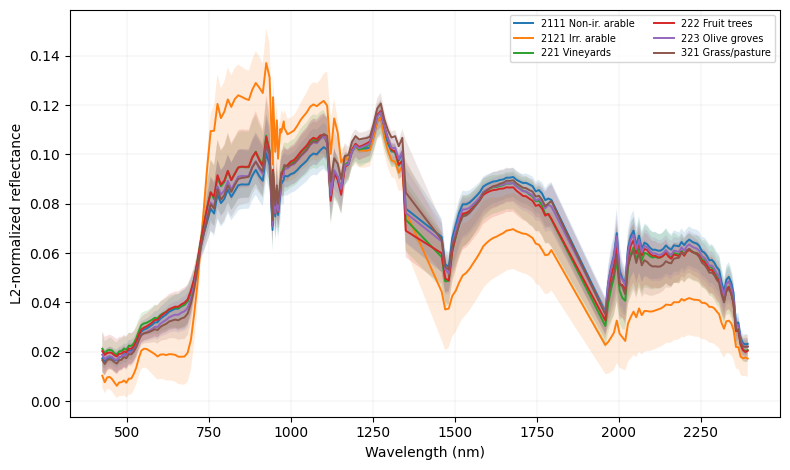

In [43]:
###########################################
    # only for prototypes figure generation
###########################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Classi rappresentative
selected_classes = {
    2111: "Non-ir. arable",
    2121: "Irr. arable",
    221: "Vineyards",
    222: "Fruit trees",
    223: "Olive groves",
    321: "Grass/pasture",
}

# Se hai wavelengths in un file CSV
#wavelengths = pd.read_csv("/kaggle/input/datasets/andgu2026/new-seed/wavelengths_retained.csv/wavelengths_retained.csv", header=None).values.ravel()
wavelengths = pd.read_csv(
    "/kaggle/input/datasets/andgu2026/new-seed/wavelengths_retained.csv",
    header=None
).values.ravel()
# Se non hai ancora wavelengths, usa l'indice banda come fallback temporaneo
# Meglio però usare le lunghezze d'onda reali.
if "wavelengths" not in globals():
    wavelengths = np.arange(X_norm.shape[1])

fig, ax = plt.subplots(figsize=(8, 4.8))

for class_code, label in selected_classes.items():
    if class_code not in prototypes:
        print(f"Skipping class {class_code}: no prototype available")
        continue

    idx = meta["y"].to_numpy() == class_code
    Xc = X_norm[idx, :]

    proto = prototypes[class_code]
    q25 = np.nanpercentile(Xc, 25, axis=0)
    q75 = np.nanpercentile(Xc, 75, axis=0)

    ax.plot(wavelengths, proto, linewidth=1.4, label=f"{class_code} {label}")
    ax.fill_between(wavelengths, q25, q75, alpha=0.15)

ax.set_xlabel("Wavelength (nm)" if np.nanmax(wavelengths) > 100 else "Band index")
ax.set_ylabel("L2-normalized reflectance")
# ax.set_title("Representative SIT class prototypes and interquartile envelopes")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, linewidth=0.3, alpha=0.4)

fig.tight_layout()

out_path = OUTPUT_ROOT / "fig_prototype_spectra_envelopes.pdf"
fig.savefig(out_path, bbox_inches="tight")
fig.savefig(OUTPUT_ROOT / "fig_prototype_spectra_envelopes.png", dpi=300, bbox_inches="tight")

print(out_path)

In [10]:
 
import pandas as pd
import numpy as np

# Usa l'audit già calcolato per il seed 49
df = field_audit_49.copy()

# Controllo colonne
print(df.columns.tolist())

# Solo unità eleggibili
eligible = df[df["eligible"] == True].copy()

print("Total field-scene units:", len(df))
print("Eligible units:", len(eligible))

# Soglie realizzate
tau10 = eligible["S_f"].quantile(0.10)
tau30 = eligible["S_f"].quantile(0.30)
omega90 = eligible["o_f"].quantile(0.90)

print("tau10 =", tau10)
print("tau30 =", tau30)
print("omega90 =", omega90)

# Decomposizione trigger SA
low_support = eligible["S_f"] <= tau10
high_outlier = eligible["o_f"] >= omega90
sa = low_support | high_outlier

low_only = low_support & ~high_outlier
outlier_only = high_outlier & ~low_support
both = low_support & high_outlier

sa_total = int(sa.sum())

trigger_summary = pd.DataFrame([
    {
        "quantity": "tau10_S_f",
        "value": tau10,
        "count": np.nan,
        "share_of_SA_percent": np.nan,
    },
    {
        "quantity": "tau30_S_f",
        "value": tau30,
        "count": np.nan,
        "share_of_SA_percent": np.nan,
    },
    {
        "quantity": "omega90_o_f",
        "value": omega90,
        "count": np.nan,
        "share_of_SA_percent": np.nan,
    },
    {
        "quantity": "SA_total",
        "value": np.nan,
        "count": sa_total,
        "share_of_SA_percent": 100.0,
    },
    {
        "quantity": "low_S_f_only",
        "value": np.nan,
        "count": int(low_only.sum()),
        "share_of_SA_percent": 100 * int(low_only.sum()) / sa_total,
    },
    {
        "quantity": "high_o_f_only",
        "value": np.nan,
        "count": int(outlier_only.sum()),
        "share_of_SA_percent": 100 * int(outlier_only.sum()) / sa_total,
    },
    {
        "quantity": "both_triggers",
        "value": np.nan,
        "count": int(both.sum()),
        "share_of_SA_percent": 100 * int(both.sum()) / sa_total,
    },
])

trigger_summary.to_csv(
    OUTPUT_ROOT / "main_thresholds_sa_trigger_summary_seed_49.csv",
    index=False
)

display(trigger_summary)

['scene_id', 'field_id', 'unit_id', 'class_code', 'n_pixels', 'n_supported_pixels', 'S_f', 'o_f', 'too_small', 'insufficient_class_support', 'eligible', 'tau10', 'tau30', 'omega90', 'audit_flag']
Total field-scene units: 190797
Eligible units: 40632
tau10 = 0.3397918138525022
tau30 = 0.7293689838355626
omega90 = 0.07618012422360264


,quantity,value,count,share_of_SA_percent
0,tau10_S_f,0.339792,NaN,NaN
1,tau30_S_f,0.729369,NaN,NaN
2,omega90_o_f,0.076180,NaN,NaN
3,SA_total,NaN,5667.0,100.000000
4,low_S_f_only,NaN,1603.0,28.286571
5,high_o_f_only,NaN,1603.0,28.286571
6,both_triggers,NaN,2461.0,43.426857


## 5. Compare SA sets across seeds

This optional cell produces the final sensitivity table with SA rate, Jaccard overlap, recall of the reference SA set, and Spearman correlation of field-level support scores.


In [24]:
def compare_seed_audits(output_root: Path, seeds, reference_seed: int):
    audits = {}

    for seed in seeds:
        path = output_root / f"field_audit_seed_{seed}.csv"
        if not path.exists():
            raise FileNotFoundError(path)

        df = pd.read_csv(path)

        df["scene_id"] = df["scene_id"].astype(str)
        df["field_id"] = df["field_id"].astype(str)
        df["unit_id"] = df["scene_id"] + "__" + df["field_id"]

        audits[seed] = df

    ref = audits[reference_seed]

    ref_sa = set(
        ref.loc[ref["audit_flag"] == "spectrally_atypical", "unit_id"]
    )

    rows = []

    for seed in seeds:
        df = audits[seed]

        eligible = int(df["eligible"].sum())
        sa_units = set(
            df.loc[df["audit_flag"] == "spectrally_atypical", "unit_id"]
        )

        n_sa = len(sa_units)
        sa_rate = 100 * n_sa / eligible if eligible > 0 else np.nan

        if seed == reference_seed:
            jaccard = np.nan
            recall = np.nan
            rho_score = 1.0
            sa_diff = 0
            common_units = len(df)
            common_valid_score_units = len(df.loc[df["S_f"].notna()])
        else:
            inter = len(ref_sa & sa_units)
            union = len(ref_sa | sa_units)

            jaccard = 100 * inter / union if union > 0 else np.nan
            recall = 100 * inter / len(ref_sa) if len(ref_sa) > 0 else np.nan
            sa_diff = n_sa - len(ref_sa)

            merged = ref[["unit_id", "S_f", "eligible"]].merge(
                df[["unit_id", "S_f", "eligible"]],
                on="unit_id",
                suffixes=("_ref", "_seed")
            )

            common_units = len(merged)

            # Keep only units that are eligible in both seeds and have valid S_f
            merged_valid = merged[
                (merged["eligible_ref"] == True) &
                (merged["eligible_seed"] == True) &
                merged["S_f_ref"].notna() &
                merged["S_f_seed"].notna()
            ].copy()

            common_valid_score_units = len(merged_valid)

            if common_valid_score_units > 2:
                if SCIPY_AVAILABLE:
                    rho_score = spearmanr(
                        merged_valid["S_f_ref"],
                        merged_valid["S_f_seed"]
                    ).correlation
                else:
                    rho_score = merged_valid["S_f_ref"].corr(
                        merged_valid["S_f_seed"],
                        method="spearman"
                    )
            else:
                rho_score = np.nan

        rows.append({
            "seed": seed,
            "eligible": eligible,
            "SA": n_sa,
            "SA_rate_percent": sa_rate,
            "Jaccard_percent": jaccard,
            "main_recall_percent": recall,
            "rho_score": rho_score,
            "SA_diff": sa_diff,
            "common_units_with_reference": common_units,
            "common_valid_score_units": common_valid_score_units,
        })

    summary = pd.DataFrame(rows)
    return summary

In [21]:
def compare_seed_audits(output_root: Path, seeds, reference_seed: int):
    audits = {}

    for seed in seeds:
        path = output_root / f"field_audit_seed_{seed}.csv"
        if not path.exists():
            raise FileNotFoundError(path)

        df = pd.read_csv(path)
        df["scene_id"] = df["scene_id"].astype(str)
        df["field_id"] = df["field_id"].astype(str)
        df["unit_id"] = df["scene_id"] + "__" + df["field_id"]
        audits[seed] = df

    ref = audits[reference_seed]
    ref_sa = set(ref.loc[ref["audit_flag"] == "spectrally_atypical", "unit_id"])

    rows = []

    for seed in seeds:
        df = audits[seed]

        eligible = int(df["eligible"].sum())
        sa_units = set(df.loc[df["audit_flag"] == "spectrally_atypical", "unit_id"])

        n_sa = len(sa_units)
        sa_rate = 100 * n_sa / eligible if eligible > 0 else np.nan

        if seed == reference_seed:
            jaccard = np.nan
            recall = np.nan
            rho_score = 1.0
            sa_diff = 0
            common_units = len(df)
        else:
            inter = len(ref_sa & sa_units)
            union = len(ref_sa | sa_units)

            jaccard = 100 * inter / union if union > 0 else np.nan
            recall = 100 * inter / len(ref_sa) if len(ref_sa) > 0 else np.nan
            sa_diff = n_sa - len(ref_sa)

            merged = ref[["unit_id", "S_f"]].merge(
                df[["unit_id", "S_f"]],
                on="unit_id",
                suffixes=("_ref", "_seed")
            )

            common_units = len(merged)

            if SCIPY_AVAILABLE and len(merged) > 2:
                rho_score = spearmanr(merged["S_f_ref"], merged["S_f_seed"]).correlation
            elif len(merged) > 2:
                rho_score = merged["S_f_ref"].corr(merged["S_f_seed"], method="spearman")
            else:
                rho_score = np.nan

        rows.append({
            "seed": seed,
            "eligible": eligible,
            "SA": n_sa,
            "SA_rate_percent": sa_rate,
            "Jaccard_percent": jaccard,
            "main_recall_percent": recall,
            "rho_score": rho_score,
            "SA_diff": sa_diff,
            "common_units_with_reference": common_units,
        })

    summary = pd.DataFrame(rows)
    return summary


cap_seed_sensitivity = compare_seed_audits(OUTPUT_ROOT, SEEDS, REFERENCE_SEED)

summary_path = OUTPUT_ROOT / "cap_seed_sensitivity_summary.csv"
cap_seed_sensitivity.to_csv(summary_path, index=False)

print("Saved:", summary_path)
display(cap_seed_sensitivity)


Saved: /kaggle/working/audit_seed_outputs/cap_seed_sensitivity_summary.csv


,seed,eligible,SA,SA_rate_percent,Jaccard_percent,main_recall_percent,rho_score,SA_diff,common_units_with_reference
0,49,40632,5667,13.947135,NaN,NaN,1.0,0,190797
1,7,40720,5722,14.052063,57.633218,73.478031,NaN,55,170735
2,123,40647,5728,14.092061,56.847901,72.878066,NaN,61,170584


In [25]:
cap_seed_sensitivity = compare_seed_audits(OUTPUT_ROOT, SEEDS, REFERENCE_SEED)

summary_path = OUTPUT_ROOT / "cap_seed_sensitivity_summary.csv"
cap_seed_sensitivity.to_csv(summary_path, index=False)

display(cap_seed_sensitivity)

,seed,eligible,SA,SA_rate_percent,Jaccard_percent,main_recall_percent,rho_score,SA_diff,common_units_with_reference,common_valid_score_units
0,49,40632,5667,13.947135,NaN,NaN,1.000000,0,190797,190448
1,7,40720,5722,14.052063,57.633218,73.478031,0.915447,55,170735,35009
2,123,40647,5728,14.092061,56.847901,72.878066,0.914674,61,170584,34950


## 6. Produce a LaTeX table

This cell writes a compact LaTeX table for the appendix.


In [26]:
def fmt_int(x):
    return f"{int(x):,}".replace(",", "\\,")


def fmt_float(x, nd=1, dash_for_nan=True):
    if pd.isna(x):
        return "--" if dash_for_nan else "nan"
    return f"{float(x):.{nd}f}"


def make_latex_cap_seed_table(summary: pd.DataFrame, reference_seed: int) -> str:
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\scriptsize")
    lines.append(r"\setlength{\tabcolsep}{3pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.05}")
    lines.append(r"\caption{Sensitivity of the spectral-support audit to the random seed used for")
    lines.append(r"the 100,000-pixel per-scene cap.}")
    lines.append(r"\label{tab:sensitivity_cap_seed}")
    lines.append(r"\begin{tabular}{lrrrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Seed & Elig. & SA & SA (\%) & Jac. & Rec. & $\rho(S_f)$ \\")
    lines.append(r"\midrule")

    for _, row in summary.iterrows():
        seed = int(row["seed"])
        seed_label = f"{seed}"
        if seed == reference_seed:
            jac = "--"
            rec = "--"
        else:
            jac = fmt_float(row["Jaccard_percent"], 1)
            rec = fmt_float(row["main_recall_percent"], 1)

        line = (
            f"{seed_label} & "
            f"{fmt_int(row['eligible'])} & "
            f"{fmt_int(row['SA'])} & "
            f"{fmt_float(row['SA_rate_percent'], 1)} & "
            f"{jac} & "
            f"{rec} & "
            f"{fmt_float(row['rho_score'], 3)} \\\\"
        )
        lines.append(line)

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append("")
    lines.append(r"\vspace{1mm}")
    lines.append(r"\footnotesize")
    lines.append(
        rf"The seed-{reference_seed} configuration is used as the reference. "
        r"SA = \texttt{spectrally\_atypical}; Elig. = eligible field--scene units; "
        r"Jac. = Jaccard overlap of the SA set relative to the reference seed; "
        r"Rec. = recall of the reference SA set; $\rho(S_f)$ = Spearman correlation "
        r"of field-level spectral-support scores on common field--scene units."
    )
    lines.append(r"\end{table}")

    return "\n".join(lines)


latex_table = make_latex_cap_seed_table(cap_seed_sensitivity, REFERENCE_SEED)

tex_path = OUTPUT_ROOT / "tab_sensitivity_cap_seed.tex"
tex_path.write_text(latex_table, encoding="utf-8")

print("Saved:", tex_path)
print(latex_table)


Saved: /kaggle/working/audit_seed_outputs/tab_sensitivity_cap_seed.tex
\begin{table}[t]
\centering
\scriptsize
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\caption{Sensitivity of the spectral-support audit to the random seed used for
the 100,000-pixel per-scene cap.}
\label{tab:sensitivity_cap_seed}
\begin{tabular}{lrrrrrr}
\toprule
Seed & Elig. & SA & SA (\%) & Jac. & Rec. & $\rho(S_f)$ \\
\midrule
49 & 40\,632 & 5\,667 & 13.9 & -- & -- & 1.000 \\
7 & 40\,720 & 5\,722 & 14.1 & 57.6 & 73.5 & 0.915 \\
123 & 40\,647 & 5\,728 & 14.1 & 56.8 & 72.9 & 0.915 \\
\bottomrule
\end{tabular}

\vspace{1mm}
\footnotesize
The seed-49 configuration is used as the reference. SA = \texttt{spectrally\_atypical}; Elig. = eligible field--scene units; Jac. = Jaccard overlap of the SA set relative to the reference seed; Rec. = recall of the reference SA set; $\rho(S_f)$ = Spearman correlation of field-level spectral-support scores on common field--scene units.
\end{table}
